# Black Hole Imaging from GRMHD Simulations

In this notebook, we explore how to generate synthetic images of black holes using data from General Relativistic Magnetohydrodynamic (GRMHD) simulations.

## First, we import the necessary functions to perform such calculations.

- The file main.jl serves as a wrapper for this for us

In [1]:
using Jipole
using StaticArrays

const MBH = 6.2e9;

### Now we point to the path of the GRMHD snapshot/dumpfile.

- Currently, Jipole only reads `iharm3d` data format.

To access the file used in this notebook, download the snapshot from [Harvard Dataverse (GRMHD snapshot)](https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/XZECPF)

In [2]:
dump_filepath = "/home/pedro/sample_dump_SANE_a+0.94_MKS_0900.h5"


"/home/pedro/sample_dump_SANE_a+0.94_MKS_0900.h5"

## Magnetization parameters

We begin by defining a set of parameters that will be used when reading and processing the GRMHD simulation data

- `trat_large:` Ratio of ion-to-electron temperature in low-magnetization regions (disk-dominated plasma). This controls how hot electrons are relative to ions in the bulk flow.
- `trat_small:` Ion-to-electron temperature ratio in highly magnetized regions (jet-dominated plasma). A value closer to 1 implies electrons and ions have similar temperatures.
- `beta_crit:` Critical plasma beta (ratio of gas pressure to magnetic pressure) that determines the transition between disk-like and jet-like thermodynamic prescriptions.
- `th_beg:`   Lower cutoff for the polar angle (in radians), typically used to exclude regions too close to the poles where numerical artifacts or low-density funnels may exist.
- `sigma_cut:` Magnetization threshold (σ = magnetic energy density / matter energy density) above which zones may be excluded or treated differently due to strong magnetic dominance.
- `sigma_cut_high:` Upper magnetization cutoff. A negative value typically indicates that no upper limit is enforced.

In [3]:
trat_large = 20. 
const trat_small = 1. 
const beta_crit = 1.0 
const th_beg = 1.74e-2 
const sigma_cut = 1.0 
const sigma_cut_high = -1.0;

## Simulation Parameters Structure
We define a `GlobalParams` structure that stores all the relevant metadata quantities describing the GRMHD simulation. These parameters are read from the simulation header and are required to interpret the data in the dump file.

### Overview

The structure includes:

- **Flags**
  - `metric`, `ELECTRONS`, `RADIATION`  
    Integer flags indicating the spacetime metric used and whether electron physics and radiation are included in the simulation.

- **Physical Parameters**
  - `gam`, `game`, `gamp`  
    Adiabatic indices for the total fluid, electrons, and protons.
  - `Te_unit`, `Thetae_unit`  
    Conversion factors for electron temperature into physical or dimensionless units.

- **Particle Weights**
  - `mu_i`, `mu_e`, `mu_tot`  
    Mean molecular weights for ions, electrons, and the total plasma.
  - `Ne_factor`  
    Scaling factor used to compute electron number density.

- **Units**
  - `M_unit`, `T_unit`, `L_unit`  
    Unit conversions for mass, time, and length.
  - `MBH`  
    Black hole mass used to scale the simulation.
  - `tp_over_te`  
    Ratio of proton to electron temperature.

- **Metric Parameters**
  - `a`  
    Dimensionless black hole spin.
  - `hslope`, `Rin`, `Rout`  
    Parameters defining the radial and angular grid structure.
  - `poly_xt`, `poly_alpha`, `mks_smooth`, `poly_norm`  
    Parameters controlling coordinate transformations and grid shaping.

- **MKS3-Specific Parameters**
  - `mks3R0`, `mks3H0`, `mks3MY1`, `mks3MY2`, `mks3MP0`  
    Additional parameters for modified Kerr–Schild (MKS3) coordinate systems.

- **Grid Configuration**
  - `N1`, `N2`, `N3`  
    Number of grid cells in each spatial dimension.
  - `dx`  
    Grid spacing in each coordinate direction.
  - `startx`, `stopx`  
    Domain boundaries.
  - `cstartx`, `cstopx`  
    Cell-centered domain boundaries.

- **Geometric Limits**
  - `rmin_geo`, `rmax_geo`  
    Minimum and maximum radii of the computational domain in geometric units.

Together, these parameters describe the simulation setup, coordinate system, physical scaling, and numerical grid.

In [4]:
const model = Jipole.Iharm.read_header(dump_filepath, MBH;
    th_beg=th_beg, trat_small=trat_small, beta_crit=beta_crit,
    sigma_cut=sigma_cut, sigma_cut_high=sigma_cut_high);

Initializing grid from: /home/pedro/sample_dump_SANE_a+0.94_MKS_0900.h5


Using Modified Kerr-Schild coordinates MKS
MKS parameters a: 0.937500 hslope: 0.300000 Rin: 1.177706 Rout: 1000.000000
Grid start (startx): 1.635684465252566e-01, 0.000000000000000e+00, 0.000000000000000e+00 stop (stopx): 6.907755278982137e+00, 1.000000000000000e+00, 6.283185307179586e+00
grid dx: 2.341731539047528e-02, 7.812500000000000e-03, 4.908738521234052e-02


## Simulation Data (Primitive Variables)

The simulation data structure stores the **primitive variables** extracted from the GRMHD dump file, along with some derived quantities.
### Primitive Variables
- `RHO`  
  Rest-mass density of the fluid.
- `UU`  
  Internal energy density.
- `U1`, `U2`, `U3`  
  Spatial components of the fluid 4-velocity.
- `B1`, `B2`, `B3`  
  Magnetic field components defined in the simulation frame.
### Derived Quantities
- `ne`  
  Electron number density, computed using the density and composition assumptions.
- `b`  
  Magnetic field strength (magnitude of the magnetic 4-vector).
- `θe`  
  Dimensionless electron temperature.
- `sigma`  
  Magnetization parameter (ratio of magnetic to matter energy density).
- `beta`  
  Plasma beta, defined as the ratio of gas pressure to magnetic pressure.
- `dθedRhi`  
  Radial gradient of the electron temperature in high-magnetization regions, used when doing the autodiff analysis on Rhigh

In [5]:
const simulation_data = Vector{Jipole.Iharm.IharmData{Array{Float64,3}}}(undef, 1)
simulation_data[1] = Jipole.Iharm.load_data(dump_filepath, trat_large, model);

Loading data from '/home/pedro/sample_dump_SANE_a+0.94_MKS_0900.h5' into 'Iharm' module...
All primitives successfully loaded. Dimensions: (288, 128, 128)


## Defining the parameters for the Raytracing

In [6]:
# Observer distance in gravitational radii (Rg)
const ro = 1000.0

# Inclination angle (deg) — angle between the observer and the BH spin axis
const th = 163.0

# Azimuthal angle (deg) — rotation around the system
const phi = 0.0

# Image resolution — total geodesics traced = res^2
const res = 1024
const pixels_x = 1024
const pixels_y = 1024

# Distance to the source (in parsecs, converted to code units)
const SourceD = 16.9e6 * Jipole.Constants.PC

# Event horizon radius for a Kerr black hole
const Rh = 1 + sqrt(1. - model.a * model.a)

# Observing frequency (Hz), e.g. 230 GHz for EHT-like images
const freq = 230e9

# Image plane size (in Rg), scaled from physical distance
const DXsize = SourceD / model.L_unit / Jipole.Constants.MUAS_PER_RAD * 160
const DYsize = SourceD / model.L_unit / Jipole.Constants.MUAS_PER_RAD * 160

# Field of view (radians)
const fovx = DXsize / ro
const fovy = DYsize / ro

# Image offsets (can be used to shift the camera)
const xoff = 0.0
const yoff = 0.0

const maxnstep = 25000;


## Performing the Image calculation

In [7]:
using ProgressMeter

Xcamera = MVector{4,Float64}(Jipole.Camera.camera_position(ro, th, phi, model.a, model))
const freq_unitless = freq * Jipole.Constants.HPL / (Jipole.Constants.ME * Jipole.Constants.CL * Jipole.Constants.CL)

Image = zeros(Float64, pixels_x, pixels_y)

println("Allocating workspaces for $pixels_x row-tasks...")
dummy_svec = @SVector zeros(4)
dummy_traj = Jipole.GeoTypes.OfTrajS(0.0, dummy_svec, dummy_svec, dummy_svec, dummy_svec)


task_trajs = [Vector{Jipole.GeoTypes.OfTrajS}(undef, maxnstep) for _ in 1:pixels_x]
for i in 1:pixels_x
    for k in 1:maxnstep
        task_trajs[i][k] = dummy_traj
    end
end

p = Progress(pixels_x * pixels_y; desc = "Raytracing Image...", showspeed = true, barlen = 30)
ProgressMeter.ijulia_behavior(:clear)
progress_lock = ReentrantLock()
println("Tracing Geodesics...")
Threads.@threads :greedy for i in 0:(pixels_x - 1)
    my_traj = task_trajs[i + 1]

    for j in 0:(pixels_y - 1)
        nstep, _ = Jipole.Geodesics.get_pixel(
            my_traj, i, j, Xcamera,
            fovx, fovy, freq_unitless,
            pixels_x, pixels_y, model.a,
            Rh, model.rmax_geo, model, xoff, yoff
        )

        Jipole.Radiation.integrate_emission!(
            my_traj, nstep, Image,
            i + 1, j + 1, freq, model.a, model, simulation_data
        )

        lock(progress_lock) do
            if (i * pixels_y + j) % 2000 == 0
                ProgressMeter.next!(p; showvalues = [(:pixel, "($i, $j)"), (:total_done, "$(i*pixels_y + j)/$(pixels_x * pixels_y)")])
            else
                ProgressMeter.next!(p)
            end
        end
    end
end
Image *= freq^3
finish!(p);


Allocating workspaces for 128 row-tasks...
Tracing Geodesics...


Raytracing Image... 100%|██████████████████████████████| Time: 0:00:04 ( 0.25 ms/it)


## Print out some outputs

In [10]:
#Scale factor calculation to real units
const scale_factor = Jipole.Imaging.calculate_scale_factor(DXsize, DYsize, pixels_x, pixels_y, SourceD, model.L_unit)
Jipole.Imaging.output_stokes_parameters(Image, freq, scale_factor, pixels_x, pixels_y, SourceD)

Image processing complete. Calculating total flux and averages...
Scale = 3.6725603721607905
imax = 52, jmax = 67, Imax = 0.0009041886092215993, Iavg = 6.939776551452396e-6
Total Flux Fnu = 0.4175748850403671 Jy
nuLnu = 3.2820612962613883e40


## Plot the final image

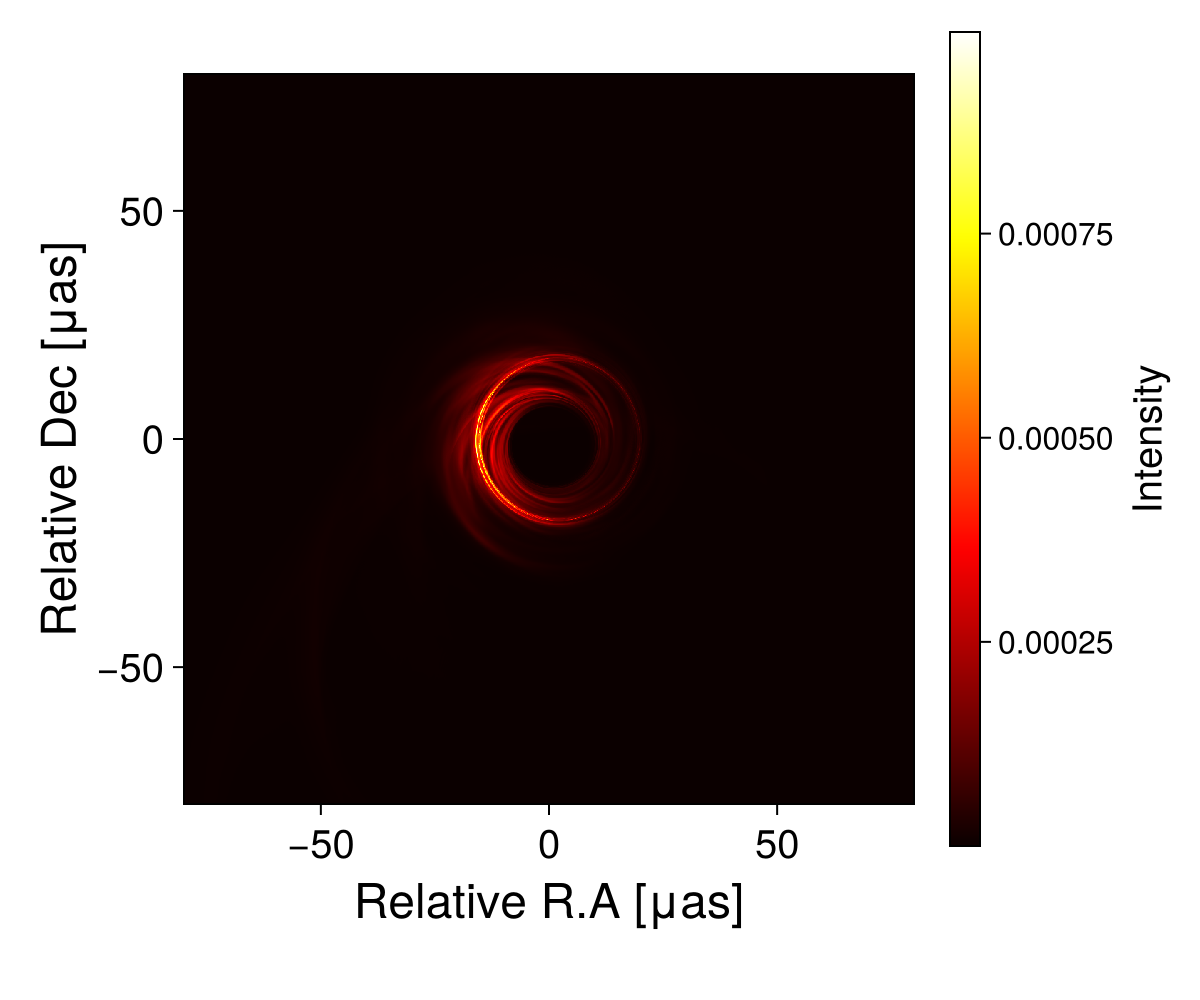

In [14]:
using CairoMakie

d_kpc = 16.9
d_cm = d_kpc * 3.086e21           
fov_rg = fovx
half_fov_rg = fov_rg / 2

theta_rad = (half_fov_rg * model.L_unit) / d_cm   
theta_μas = theta_rad * Jipole.Constants.MUAS_PER_RAD       
xlims = (-theta_μas, theta_μas)
ylims = (-theta_μas, theta_μas)

Ny, Nx = size(Image)
x = range(xlims[1], xlims[2], length=Nx)
y = range(ylims[1], ylims[2], length=Ny)

fig = Figure(size = (600, 500))

ax = Axis(fig[1, 1],
    xlabel = "Relative R.A [μas]",
    ylabel = "Relative Dec [μas]",
    xlabelsize = 24,
    ylabelsize = 24,
    xticklabelsize = 20,
    yticklabelsize = 20,
    limits = (xlims, ylims),
    aspect = DataAspect()
)

crange = extrema(Image)

hm = heatmap!(ax, x, y, Image;
    colormap = :hot,
    colorrange = crange
)

Colorbar(fig[1, 2], hm;
    label = "Intensity",
    labelsize = 20,
    ticklabelsize = 16,
    width = 15
)

fig

# Running on GPUs

In [1]:
using Jipole
using StaticArrays

const MBH = 6.2e9;

In [2]:
dump_filepath = "/home/pedro/sample_dump_SANE_a+0.94_MKS_0900.h5"


"/home/pedro/sample_dump_SANE_a+0.94_MKS_0900.h5"

In [3]:
trat_large = 20. 
const trat_small = 1. 
const beta_crit = 1.0 
const th_beg = 1.74e-2 
const sigma_cut = 1.0 
const sigma_cut_high = -1.0;

In [4]:
const model = Jipole.Iharm.read_header(dump_filepath, MBH;
    th_beg=th_beg, trat_small=trat_small, beta_crit=beta_crit,
    sigma_cut=sigma_cut, sigma_cut_high=sigma_cut_high);

Initializing grid from: /home/pedro/sample_dump_SANE_a+0.94_MKS_0900.h5


Using Modified Kerr-Schild coordinates MKS
MKS parameters a: 0.937500 hslope: 0.300000 Rin: 1.177706 Rout: 1000.000000
Grid start (startx): 1.635684465252566e-01, 0.000000000000000e+00, 0.000000000000000e+00 stop (stopx): 6.907755278982137e+00, 1.000000000000000e+00, 6.283185307179586e+00
grid dx: 2.341731539047528e-02, 7.812500000000000e-03, 4.908738521234052e-02


In [5]:
const simulation_data = Vector{Jipole.Iharm.IharmData{Array{Float64,3}}}(undef, 1)
simulation_data[1] = Jipole.Iharm.load_data(dump_filepath, trat_large, model);

Loading data from '/home/pedro/sample_dump_SANE_a+0.94_MKS_0900.h5' into 'Iharm' module...
All primitives successfully loaded. Dimensions: (288, 128, 128)


In [10]:
# Observer distance in gravitational radii (Rg)
const ro = 1000.0

# Inclination angle (deg) — angle between the observer and the BH spin axis
const th = 163.0

# Azimuthal angle (deg) — rotation around the system
const phi = 0.0

# Image resolution — total geodesics traced = res^2
const pixels_x = 1024
const pixels_y = 1024

# Distance to the source (in parsecs, converted to code units)
const SourceD = 16.9e6 * Jipole.Constants.PC

# Event horizon radius for a Kerr black hole
const Rh = 1 + sqrt(1. - model.a * model.a)

# Observing frequency (Hz), e.g. 230 GHz for EHT-like images
const freq = 230e9

# Image plane size (in Rg), scaled from physical distance
const DXsize = SourceD / model.L_unit / Jipole.Constants.MUAS_PER_RAD * 160
const DYsize = SourceD / model.L_unit / Jipole.Constants.MUAS_PER_RAD * 160

# Field of view (radians)
const fovx = DXsize / ro
const fovy = DYsize / ro

# Image offsets (can be used to shift the camera)
const xoff = 0.0
const yoff = 0.0

# Where to stop geodesic integration
const Rstop = 100.0;


In [11]:
using CUDA
#First, we clear the arrays
d_Image = nothing
d_traj = nothing
gpu_sim_data = nothing

# Then we allocate Image
d_Image       = CUDA.zeros(Float64, pixels_x, pixels_y)
maxnstep = 9000
block_size = 64
d_traj = CuArray{Jipole.GeoTypes.OfTrajGRMHD}(undef, block_size, block_size, maxnstep)
threads_per_block = (16, 16)
blocks_per_grid   = (cld(block_size, threads_per_block[1]), cld(block_size, threads_per_block[2]))

println("Copying simulation data grids to the GPU...")

gpu_sim_data = (Jipole.Utils_GPU.copy_iharm_to_gpu(simulation_data[1]),)
gpu_params = model;

Copying simulation data grids to the GPU...


In [12]:
println("Processing image in tiles...")

CUDA.@time begin
    # Loop over the image grid in steps of block_size
    for i_offset in 0:block_size:(pixels_x - 1)
        for j_offset in 0:block_size:(pixels_y - 1)
            
            @cuda threads=threads_per_block blocks=blocks_per_grid Jipole.Imaging.raytrace_image_gpu!(
                d_traj, d_Image,
                i_offset, j_offset, block_size, block_size,
                ro, th, phi, model.a, pixels_x, pixels_y, maxnstep,
                freq, fovx, fovy, model.Rout, Rstop, gpu_sim_data, gpu_params
            )
            
        end
    end
    CUDA.synchronize()
end

h_Image = Array(d_Image)
println("Raytracing complete!")

Processing image in tiles...
 46.277005 seconds (14.32 k CPU allocations: 1.207 MiB, 0.01% gc time)
Raytracing complete!


In [9]:
#Scale factor calculation to real units
const scale_factor = Jipole.Imaging.calculate_scale_factor(DXsize, DYsize, pixels_x, pixels_y, SourceD, model.L_unit)
Jipole.Imaging.output_stokes_parameters(h_Image, freq, scale_factor, pixels_x, pixels_y, SourceD)

Image processing complete. Calculating total flux and averages...
Scale = 3.6725603721607905
imax = 52, jmax = 67, Imax = 0.0009041886092215364, Iavg = 6.939776551452611e-6
Total Flux Fnu = 0.4175748850403801 Jy
nuLnu = 3.2820612962614903e40


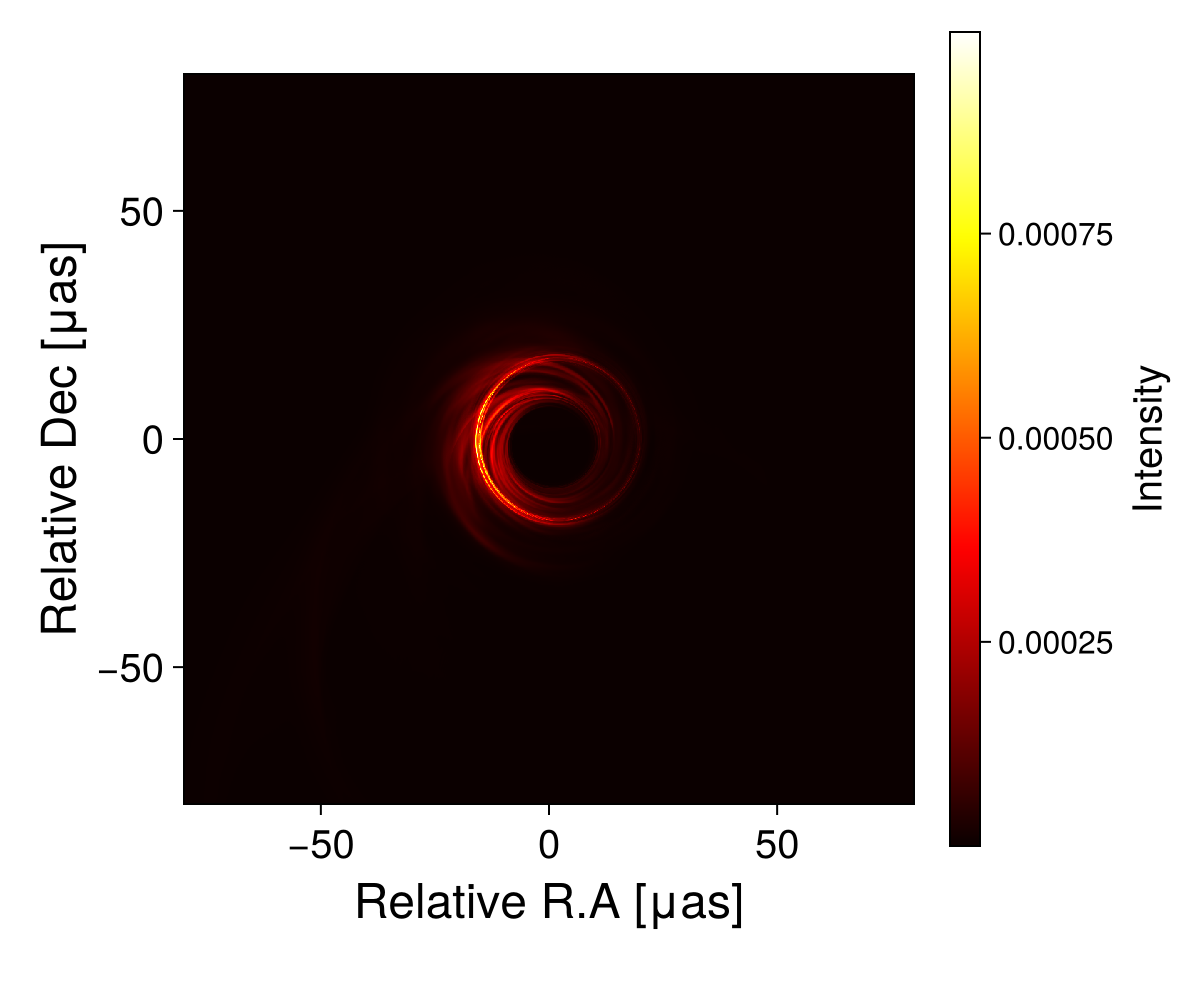

In [9]:
using CairoMakie

d_kpc = 16.9
d_cm = d_kpc * 3.086e21           
fov_rg = fovx
half_fov_rg = fov_rg / 2

theta_rad = (half_fov_rg * model.L_unit) / d_cm   
theta_μas = theta_rad * Jipole.Constants.MUAS_PER_RAD       
xlims = (-theta_μas, theta_μas)
ylims = (-theta_μas, theta_μas)

Ny, Nx = size(h_Image)
x = range(xlims[1], xlims[2], length=Nx)
y = range(ylims[1], ylims[2], length=Ny)

fig = Figure(size = (600, 500))

ax = Axis(fig[1, 1],
    xlabel = "Relative R.A [μas]",
    ylabel = "Relative Dec [μas]",
    xlabelsize = 24,
    ylabelsize = 24,
    xticklabelsize = 20,
    yticklabelsize = 20,
    limits = (xlims, ylims),
    aspect = DataAspect()
)

crange = extrema(h_Image)

hm = heatmap!(ax, x, y, h_Image;
    colormap = :hot,
    colorrange = crange
)

Colorbar(fig[1, 2], hm;
    label = "Intensity",
    labelsize = 20,
    ticklabelsize = 16,
    width = 15
)

fig